Imports

In [1]:
import os
import pandas as pd
import numpy as np
import time
import xlsxwriter
from xlsxwriter.utility import xl_rowcol_to_cell
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import pickle


from utils import *

# change the font to LM Roman 12
import matplotlib.font_manager as fm
fm.fontManager.addfont('C://Users//hoel_m0//AppData//Local//Microsoft//Windows//Fonts//latin-modern-roman.mroman12-regular.otf')
plt.rcParams['font.family'] = 'Latin Modern Roman'
# make the font size larger
plt.rcParams.update({'font.size': 13})

# custom define colours
blue = '#00668d'
light_blue = '#0099CE'
green = '#73a237'
light_green = '#9cc045'
gray = '#686867'
light_gray = '#b2b2b2'
yellow = '#e0b02e'
light_yellow = '#ffce44'
red = '#a44a3f'
purple = '#49111c'
pink = '#d88c9a'

# change the font to Frutiger
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Frutiger']

In [2]:
# Set functional units (more descriptive names can be added)
fu_list = ['FC', 'FH', 'ASK', 'Month', 'Year', 'Life']

# Header names
# headers = ['Parameter', 'ADP', 'CC', 'FETP', 'FEP', 'MEP', 'TEP', 'HHC', 'HHNC', 'IR', 'LU', 'MM', 'ODP', 'PM', 'POxF', 'WS']
headers = ['Parameter', 'ADP', 'FETP', 'TEP', 'HHC', 'HHNC', 'ODP', 'CC', 'ECF', 'FEP', 'MEP', 'IR', 'LU', 'MM', 'PM', 'POxF', 'WS']
impact_categories = headers[1:]

# Columns to read from the excel files
columns = 'B,F,G,K,L,P,T,U,Y,Z,AA,AB,AC,AD,AE,AF,AG'

overview_data = pd.read_excel(r"G:\Studenten\PLM\MariaHoeller\Overview_Individual_LCAs.xlsx")

# Read deterministic scores from reference case
output_folder_path = r"C:\Git_LYFE\airlyfe\projects\thesis_mc_1_attempt2\outputs"
referencecase_path = os.path.join(output_folder_path, "D250-TF_eco.xlsx")

# read the deterministic results into a dataframe
deterministic_inputs = pd.read_excel(referencecase_path, sheet_name="Individual LCAs", usecols=columns, skiprows=3, nrows=34)
deterministic_outputs = pd.read_excel(referencecase_path, sheet_name="Summary", usecols="D:I", skiprows=30, nrows=16)

In [3]:
import os
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Function to process each file
def process_file(file):
    try:
        if file.endswith("_eco.xlsx") and not file.startswith("D250-TF"):
            file_path = os.path.join(output_folder_path, file)
            
            # Read sheets into dataframes
            summary = pd.read_excel(file_path, sheet_name='Summary', header=None)
            # individual_lcas = pd.read_excel(file_path, sheet_name='Individual LCAs', header=None)
            production = pd.read_excel(file_path, sheet_name='Production', header=None)
            flight_ops = pd.read_excel(file_path, sheet_name='Flight Operations', header=None)
            maintenance = pd.read_excel(file_path, sheet_name='Maintenance', header=None)
            eol = pd.read_excel(file_path, sheet_name='End-of-Life', header=None)
            
            file_name = file

            return summary, production, flight_ops, maintenance, eol, file_name

    except Exception as e:
        print(f"An error occurred with file {file}: {e}")
        return None, None, None, None, None

# Setup paths and read file list
file_list = os.listdir(output_folder_path)
file_list = [file for file in file_list if file.endswith("_eco.xlsx") and not file.startswith("D250-TF")]
# file_list = file_list[:150]  
print(f"Total files to process: {len(file_list)}")

summary_list = []
production_list = []
flight_ops_list = []
maintenance_list = []
eol_list = []
file_name_list = []

# Configure number of workers based on system capacity
num_workers = min(60, os.cpu_count())

# Process files in parallel using ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    futures = {executor.submit(process_file, file): file for file in file_list}

    # Collect results as they complete
    for future in tqdm(as_completed(futures), total=len(futures)):
        results = future.result()
        
        # Ensure results is not None before checking contents
        if results is not None and all(result is not None for result in results):
            summary, production, flight_ops, maintenance, eol, file_name = results
            
            summary_list.append(summary)
            production_list.append(production)
            flight_ops_list.append(flight_ops)
            maintenance_list.append(maintenance)
            eol_list.append(eol)
            file_name_list = file_name

print(f"Successfully processed data from {len(summary_list)} files in the folder {output_folder_path}")



Total files to process: 4461


100%|██████████| 4461/4461 [1:27:51<00:00,  1.18s/it]

Successfully processed data from 4461 files in the folder C:\Git_LYFE\airlyfe\projects\thesis_mc_1_attempt2\outputs


In [4]:
# Function to process each file
def process_file(file):
    try:
        if file.endswith("_eco.xlsx") and not file.startswith("D250-TF"):
            file_path = os.path.join(output_folder_path_2, file)
            
            # Read sheets into dataframes
            summary = pd.read_excel(file_path, sheet_name='Summary', header=None)
            # individual_lcas = pd.read_excel(file_path, sheet_name='Individual LCAs', header=None)
            production = pd.read_excel(file_path, sheet_name='Production', header=None)
            flight_ops = pd.read_excel(file_path, sheet_name='Flight Operations', header=None)
            maintenance = pd.read_excel(file_path, sheet_name='Maintenance', header=None)
            eol = pd.read_excel(file_path, sheet_name='End-of-Life', header=None)
            
            file_name = file

            return summary, production, flight_ops, maintenance, eol, file_name

    except Exception as e:
        print(f"An error occurred with file {file}: {e}")
        return None, None, None, None, None

output_folder_path_2 = r"C:\Git_LYFE\airlyfe\projects\thesis_mc_2\outputs"

# Setup paths and read file list
file_list2 = os.listdir(output_folder_path_2)
file_list2 = [file for file in file_list2 if file.endswith("_eco.xlsx") and not file.startswith("D250-TF")]
# file_list2 = file_list2[:150]  
print(f"Total files to process: {len(file_list2)}")

summary_list2 = []
production_list2 = []
flight_ops_list2 = []
maintenance_list2 = []
eol_list2 = []
file_name_list2 = []

# Configure number of workers based on system capacity
num_workers = min(60, os.cpu_count())

# Process files in parallel using ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    futures = {executor.submit(process_file, file): file for file in file_list2}

    # Collect results as they complete
    for future in tqdm(as_completed(futures), total=len(futures)):
        results = future.result()
        
        # Ensure results is not None before checking contents
        if results is not None and all(result is not None for result in results):
            summary, production, flight_ops, maintenance, eol, file_name = results
            
            summary_list2.append(summary)
            production_list2.append(production)
            flight_ops_list2.append(flight_ops)
            maintenance_list2.append(maintenance)
            eol_list2.append(eol)
            file_name_list2 = file_name

print(f"Successfully processed data from {len(summary_list2)} files in the folder {output_folder_path_2}")

Total files to process: 5000


100%|██████████| 5000/5000 [59:49<00:00,  1.39it/s]  

Successfully processed data from 5000 files in the folder C:\Git_LYFE\airlyfe\projects\thesis_mc_2\outputs


In [208]:
path_1 = r"C:\Git_LYFE\airlyfe\projects\thesis_mc_1_attempt2\outputs"
deterministic_result_file_1 = os.path.join(path_1, "D250-TF_eco.xlsx")

path_2 = r"C:\Git_LYFE\airlyfe\projects\thesis_mc_2\outputs"
deterministic_result_file_2 = os.path.join(path_2, "D250-TFLH2-MHEP_eco.xlsx")

# Read sheets into dataframes
summary_det_1 = pd.read_excel(deterministic_result_file_1, sheet_name='Summary', header=None)
# individual_lcas = pd.read_excel(file_path, sheet_name='Individual LCAs', header=None)
production_det_1 = pd.read_excel(deterministic_result_file_1, sheet_name='Production', header=None)
flight_ops_det_1 = pd.read_excel(deterministic_result_file_1, sheet_name='Flight Operations', header=None)
maintenance_det_1 = pd.read_excel(deterministic_result_file_1, sheet_name='Maintenance', header=None)
eol_det_1 = pd.read_excel(deterministic_result_file_1, sheet_name='End-of-Life', header=None)

# Read sheets into dataframes
summary_det_2 = pd.read_excel(deterministic_result_file_2, sheet_name='Summary', header=None)
# individual_lcas = pd.read_excel(file_path, sheet_name='Individual LCAs', header=None)
production_det_2 = pd.read_excel(deterministic_result_file_2, sheet_name='Production', header=None)
flight_ops_det_2 = pd.read_excel(deterministic_result_file_2, sheet_name='Flight Operations', header=None)
maintenance_det_2 = pd.read_excel(deterministic_result_file_2, sheet_name='Maintenance', header=None)
eol_det_2 = pd.read_excel(deterministic_result_file_2, sheet_name='End-of-Life', header=None)

result_det_1 = {
    'aggregated': {},
    'production': {},
    'flight_ops': {},
    'maintenance': {},
    'eol': {}
}
result_det_2 = result_det_1.copy()

for impcat_idx, impact_category in enumerate(impact_categories):
        
    # store the nominal values of the outputs
    result_det_1['aggregated'][impact_category] = {}
    for fu_idx, fu in enumerate(fu_list):
        result_det_1['aggregated'][impact_category][fu] = summary_det_1.iloc[31+impcat_idx][fu_idx+3]
        result_det_2['aggregated'][impact_category][fu] = summary_det_2.iloc[31+impcat_idx][fu_idx+3]

    result_det_1['production'][impact_category] = production_det_1.iloc[8, 3+impcat_idx]
    result_det_1['flight_ops'][impact_category] = flight_ops_det_1.iloc[8, 3+impcat_idx]
    result_det_1['maintenance'][impact_category] = maintenance_det_1.iloc[8, 3+impcat_idx]
    result_det_1['eol'][impact_category] = eol_det_1.iloc[8, 3+impcat_idx]
    
    result_det_2['production'][impact_category] = production_det_2.iloc[8, 3+impcat_idx]
    result_det_2['flight_ops'][impact_category] = flight_ops_det_2.iloc[8, 3+impcat_idx]
    result_det_2['maintenance'][impact_category] = maintenance_det_2.iloc[8, 3+impcat_idx]
    result_det_2['eol'][impact_category] = eol_det_2.iloc[8, 3+impcat_idx]

In [5]:
result_list = []

for i, (summary, production, flight_ops, maintenance, eol, file) in enumerate(zip(summary_list, production_list, flight_ops_list, maintenance_list, eol_list, file_list)):
    
    result = {
        'aggregated': {},
        'production': {},
        'flight_ops': {},
        'maintenance': {},
        'eol': {}
    }
           
    for impcat_idx, impact_category in enumerate(impact_categories):
            
        # store the nominal values of the outputs
        result['aggregated'][impact_category] = {}
        for fu_idx, fu in enumerate(fu_list):
            result['aggregated'][impact_category][fu] = summary.iloc[31+impcat_idx][fu_idx+3]

        result['production'][impact_category] = production.iloc[8, 3+impcat_idx]
        result['flight_ops'][impact_category] = flight_ops.iloc[8, 3+impcat_idx]
        result['maintenance'][impact_category] = maintenance.iloc[8, 3+impcat_idx]
        result['eol'][impact_category] = eol.iloc[8, 3+impcat_idx]
        
    result_list.append(result)
    
    if i==0:
        print(file)
        print(result['aggregated'])
        print(result['production'])
        print(result['flight_ops'])
        print(result['maintenance'])
        print(result['eol'])
        
with open('result_list.pkl', 'wb') as f:
    pickle.dump(result_list, f)

prefcase_1000_eco.xlsx
{'ADP': {'FC': 123.1853669104129, 'FH': 70.41291845739278, 'ASK': 0.0004424114884411325, 'Month': 22760.96024403699, 'Year': 273131.5229284439, 'Life': 6828288.073211097}, 'FETP': {'FC': 33278.29254976306, 'FH': 19021.91598302293, 'ASK': 0.1195166220548523, 'Month': 6148830.11441972, 'Year': 73785961.37303664, 'Life': 1844649034.325916}, 'TEP': {'FC': 617105.5985294633, 'FH': 352738.3753336261, 'ASK': 2.216290889236275, 'Month': 114022601.4402889, 'Year': 1368271217.283467, 'Life': 34206780432.08668}, 'HHC': {'FC': 275867.7048511702, 'FH': 157686.3445220747, 'ASK': 0.9907592515010692, 'Month': 50972075.82535073, 'Year': 611664909.9042088, 'Life': 15291622747.60522}, 'HHNC': {'FC': 0.332097045961161, 'FH': 0.1898271101811168, 'ASK': 1.192702932950074e-06, 'Month': 61.36157118224371, 'Year': 736.3388541869246, 'Life': 18408.47135467311}, 'ODP': {'FC': 5.351289974682629e-07, 'FH': 3.05880441873604e-07, 'ASK': 1.921877753955311e-12, 'Month': 9.887578486221094e-05, 'Y

In [6]:
result_list2 = []

for i, (summary, production, flight_ops, maintenance, eol, file) in enumerate(zip(summary_list2, production_list2, flight_ops_list2, maintenance_list2, eol_list2, file_list2)):
    
    result = {
        'aggregated': {},
        'production': {},
        'flight_ops': {},
        'maintenance': {},
        'eol': {}
    }
           
    for impcat_idx, impact_category in enumerate(impact_categories):
            
        # store the nominal values of the outputs
        result['aggregated'][impact_category] = {}
        for fu_idx, fu in enumerate(fu_list):
            result['aggregated'][impact_category][fu] = summary.iloc[31+impcat_idx][fu_idx+3]

        result['production'][impact_category] = production.iloc[8, 3+impcat_idx]
        result['flight_ops'][impact_category] = flight_ops.iloc[8, 3+impcat_idx]
        result['maintenance'][impact_category] = maintenance.iloc[8, 3+impcat_idx]
        result['eol'][impact_category] = eol.iloc[8, 3+impcat_idx]
        
    result_list2.append(result)
    
    if i==0:
        print(file)
        print(result['aggregated'])
        print(result['production'])
        print(result['flight_ops'])
        print(result['maintenance'])
        print(result['eol'])

with open('result_list2.pkl', 'wb') as f:
    pickle.dump(result_list2, f)


prefcase_0_eco.xlsx
{'ADP': {'FC': 181.0899504350961, 'FH': 101.0930523847793, 'ASK': 0.0006343184709838079, 'Month': 173.8463524176922, 'Year': 2086.156229012307, 'Life': 52153.90572530766}, 'FETP': {'FC': 96006.84843926335, 'FH': 53595.60447859632, 'ASK': 0.3362909822419678, 'Month': 92166.57450169281, 'Year': 1105998.894020314, 'Life': 27649972.35050784}, 'TEP': {'FC': 1072053.775552335, 'FH': 598471.5785211716, 'ASK': 3.755169793171382, 'Month': 1029171.624530241, 'Year': 12350059.4943629, 'Life': 308751487.3590724}, 'HHC': {'FC': 219821.5254931781, 'FH': 122714.8659469573, 'ASK': 0.7699867033214307, 'Month': 211028.664473451, 'Year': 2532343.973681412, 'Life': 63308599.34203529}, 'HHNC': {'FC': 1.054653638946544, 'FH': 0.5887579918910731, 'ASK': 3.694220922070717e-06, 'Month': 1.012467493388682, 'Year': 12.14960992066419, 'Life': 303.7402480166047}, 'ODP': {'FC': 0.0005061154850919072, 'FH': 0.0002825378168375058, 'ASK': 1.772811798078156e-09, 'Month': 0.0004858708656882309, 'Year

In [3]:
with open('result_list.pkl', 'rb') as f:
    result_list = pickle.load(f)
    
with open('result_list2.pkl', 'rb') as f:
    result_list2 = pickle.load(f)

print(len(result_list))
print(len(result_list2))

# if a result in the result list is negative, set it to its absolute value
for i, result in enumerate(result_list):
    for impact_category in impact_categories:
        for fu in fu_list:
            if result['aggregated'][impact_category][fu] < 0:
                result['aggregated'][impact_category][fu] = abs(result['aggregated'][impact_category][fu])
                
        if result['production'][impact_category] < 0:
            result['production'][impact_category] = abs(result['production'][impact_category])
        if result['flight_ops'][impact_category] < 0:
            result['flight_ops'][impact_category] = abs(result['flight_ops'][impact_category])
        if result['maintenance'][impact_category] < 0:
            result['maintenance'][impact_category] = abs(result['maintenance'][impact_category])
        if result['eol'][impact_category] < 0:
            result['eol'][impact_category] = abs(result['eol'][impact_category])

4461
5000


In [4]:
# calculate the mean, std, q25, q50, q75 of each thing in the results dictionary
areas = ['aggregated', 'production', 'flight_ops', 'maintenance', 'eol']

mean = {}
std = {}
q25 = {}
q50 = {}
q75 = {}
q25 = {}
q75 = {}

mean['aggregated'] = {}
std['aggregated'] = {}
q25['aggregated'] = {}
q50['aggregated'] = {}
q75['aggregated'] = {}
q25['aggregated'] = {}
q75['aggregated'] = {}


# calculate the values for the aggregated results (per impact category and FU)
for impact_category in impact_categories:
    
    mean['aggregated'][impact_category] = {}
    std['aggregated'][impact_category] = {}
    q25['aggregated'][impact_category] = {}
    q50['aggregated'][impact_category] = {}
    q75['aggregated'][impact_category] = {}
    q25['aggregated'][impact_category] = {}
    q75['aggregated'][impact_category] = {}
        
    for fu in fu_list:
        mean['aggregated'][impact_category][fu] = np.mean([result['aggregated'][impact_category][fu] for result in result_list])
        std['aggregated'][impact_category][fu] = np.std([result['aggregated'][impact_category][fu] for result in result_list])
        q25['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list], 10)
        q50['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list], 50)
        q75['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list], 90)
        q25['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list], 25)
        q75['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list], 75)
        
# for the other areas (production, flight_ops, maintenance, eol)
for area in areas[1:]:
    
    mean[area] = {}
    std[area] = {}
    q25[area] = {}
    q50[area] = {}
    q75[area] = {}
    q25[area] = {}
    q75[area] = {}
    
    for impact_category in impact_categories:
        
        mean[area][impact_category] = np.mean([result[area][impact_category] for result in result_list])
        std[area][impact_category] = np.std([result[area][impact_category] for result in result_list])
        q25[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list], 10)
        q50[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list], 50)
        q75[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list], 90)
        q25[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list], 25)
        q75[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list], 75)
        
print(mean['aggregated'])
print(std['aggregated'])
print(q25['aggregated'])
print(q50['aggregated'])
print(q75['aggregated'])
print(q25['aggregated'])
print(q75['aggregated'])

{'ADP': {'FC': 115.51522862377007, 'FH': 66.02865728027521, 'ASK': 0.0004148647320280043, 'Month': 21343.748792814, 'Year': 256124.98551376796, 'Life': 6403124.637844199}, 'FETP': {'FC': 38219.09200097799, 'FH': 21846.083476275086, 'ASK': 0.13726115205970915, 'Month': 7061741.629020703, 'Year': 84740899.54824843, 'Life': 2118522488.7062109}, 'TEP': {'FC': 807222.8153894047, 'FH': 461409.6276410616, 'ASK': 2.8990833588196274, 'Month': 149150559.5995003, 'Year': 1789806715.1940033, 'Life': 44745167879.85009}, 'HHC': {'FC': 254035.59063741157, 'FH': 145207.0791966415, 'ASK': 0.9123507652711247, 'Month': 46938156.08207453, 'Year': 563257872.9848944, 'Life': 14081446824.622358}, 'HHNC': {'FC': 0.2810787278503057, 'FH': 0.16066497215229128, 'ASK': 1.0094742701690344e-06, 'Month': 51.934916544900986, 'Year': 623.2189985388118, 'Life': 15580.474963470295}, 'ODP': {'FC': 2.8874326457632138e-06, 'FH': 1.6504603146995452e-06, 'ASK': 1.0370009089753653e-11, 'Month': 0.000533510929957669, 'Year': 0

In [5]:
# calculate the mean, std, q25, q50, q75 of each thing in the results dictionary
areas = ['aggregated', 'production', 'flight_ops', 'maintenance', 'eol']

mean2 = {}
std2 = {}
q252 = {}
q502 = {}
q752 = {}
q252 = {}
q752 = {}

mean2['aggregated'] = {}
std2['aggregated'] = {}
q252['aggregated'] = {}
q502['aggregated'] = {}
q752['aggregated'] = {}
q252['aggregated'] = {}
q752['aggregated'] = {}

# calculate the values for the aggregated results (per impact category and FU)
for impact_category in impact_categories:
    
    mean2['aggregated'][impact_category] = {}
    std2['aggregated'][impact_category] = {}
    q252['aggregated'][impact_category] = {}
    q502['aggregated'][impact_category] = {}
    q752['aggregated'][impact_category] = {}
    q252['aggregated'][impact_category] = {}
    q752['aggregated'][impact_category] = {}
        
    for fu in fu_list:
        mean2['aggregated'][impact_category][fu] = np.mean([result['aggregated'][impact_category][fu] for result in result_list2])
        std2['aggregated'][impact_category][fu] = np.std([result['aggregated'][impact_category][fu] for result in result_list2])
        q252['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list2], 10)
        q502['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list2], 50)
        q752['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list2], 90)
        q252['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list2], 25)
        q752['aggregated'][impact_category][fu] = np.percentile([result['aggregated'][impact_category][fu] for result in result_list2], 75)
        
# for the other areas (production, flight_ops, maintenance, eol)
for area in areas[1:]:
    
    mean2[area] = {}
    std2[area] = {}
    q252[area] = {}
    q502[area] = {}
    q752[area] = {}
    q252[area] = {}
    q752[area] = {}
    
    for impact_category in impact_categories:
        
        mean2[area][impact_category] = np.mean([result[area][impact_category] for result in result_list2])
        std2[area][impact_category] = np.std([result[area][impact_category] for result in result_list2])
        q252[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list2], 10)
        q502[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list2], 50)
        q752[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list2], 90)
        q252[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list2], 25)
        q752[area][impact_category] = np.percentile([result[area][impact_category] for result in result_list2], 75)
        
print(mean2['aggregated'])
print(std2['aggregated'])
print(q252['aggregated'])
print(q502['aggregated'])
print(q752['aggregated'])
print(q252['aggregated'])
print(q752['aggregated'])

{'ADP': {'FC': 163.268547449371, 'FH': 91.14429475754766, 'ASK': 0.0005718939959340841, 'Month': 156.73780555139615, 'Year': 1880.8536666167536, 'Life': 47021.34166541884}, 'FETP': {'FC': 82029.67877525606, 'FH': 45792.88134769091, 'ASK': 0.2873320153382135, 'Month': 78748.49162424581, 'Year': 944981.8994909496, 'Life': 23624547.48727374}, 'TEP': {'FC': 1281135.0821697444, 'FH': 715190.7417423654, 'ASK': 4.487535859903425, 'Month': 1229889.6788829549, 'Year': 14758676.14659546, 'Life': 368966903.6648864}, 'HHC': {'FC': 280979.2145397585, 'FH': 156856.0065660989, 'ASK': 0.9842087057667508, 'Month': 269740.0459581681, 'Year': 3236880.5514980177, 'Life': 80922013.78745043}, 'HHNC': {'FC': 1.6286405293394621, 'FH': 0.9091848661557764, 'ASK': 5.7047714015644915e-06, 'Month': 1.5634949081658838, 'Year': 18.761938897990603, 'Life': 469.0484724497651}, 'ODP': {'FC': 0.0005200055088977607, 'FH': 0.00029029189099157786, 'ASK': 1.8214655121097113e-09, 'Month': 0.0004992052885418502, 'Year': 0.005

Translation between the LYFE output impact categories and the actual impact categories

In [6]:
def translate(impact_category_lyfe):
    if impact_category_lyfe == 'ADP': return 'MEP'
    if impact_category_lyfe == 'FETP': return 'LU'
    if impact_category_lyfe == 'TEP': return 'ECF'
    if impact_category_lyfe == 'HHC': return 'FETP'
    if impact_category_lyfe == 'HHNC': return 'FEP'
    if impact_category_lyfe == 'ODP': return 'HHC'
    if impact_category_lyfe == 'CC': return 'HHNC'
    if impact_category_lyfe == 'ECF': return 'MM'
    if impact_category_lyfe == 'FEP': return 'TEP'
    if impact_category_lyfe == 'MEP': return 'ADP'
    if impact_category_lyfe == 'IR': return 'CC'
    if impact_category_lyfe == 'LU': return 'IR'
    if impact_category_lyfe == 'MM': return 'ODP'
    if impact_category_lyfe == 'PM': return 'PM'
    if impact_category_lyfe == 'POxF': return 'POxF'
    if impact_category_lyfe == 'WS': return 'WS'
    
def reverse_translate(impact_category):
    if impact_category == 'MEP': return 'ADP'
    if impact_category == 'LU': return 'FETP'
    if impact_category == 'ECF': return 'TEP'
    if impact_category == 'FETP': return 'HHC'
    if impact_category == 'FEP': return 'HHNC'
    if impact_category == 'HHC': return 'ODP'
    if impact_category == 'HHNC': return 'CC'
    if impact_category == 'CC': return 'IR'
    if impact_category == 'MM': return 'ECF'
    if impact_category == 'TEP': return 'FEP'
    if impact_category == 'ADP': return 'MEP'
    if impact_category == 'ODP': return 'MM'
    if impact_category == 'IR': return 'LU'
    if impact_category == 'PM': return 'PM'
    if impact_category == 'POxF': return 'POxF'
    if impact_category == 'WS': return 'WS'
    
    
impact_categories_translated = [translate(impact_category) for impact_category in impact_categories]

def reorder_list_alphabetically(list: list):
    assert len(list) == 16, "The list must contain 16 elements"
    
    list_sorted = []
    list_sorted.append(list[9])
    list_sorted.append(list[10])
    list_sorted.append(list[2])
    list_sorted.append(list[4])
    list_sorted.append(list[3])
    list_sorted.append(list[5])
    list_sorted.append(list[6])
    list_sorted.append(list[11])
    list_sorted.append(list[1])
    list_sorted.append(list[0])
    list_sorted.append(list[7])
    list_sorted.append(list[12])
    list_sorted.append(list[13])
    list_sorted.append(list[14])
    list_sorted.append(list[8])
    list_sorted.append(list[15])
    
    return list_sorted
    
    
    
    

D250-TF mean results

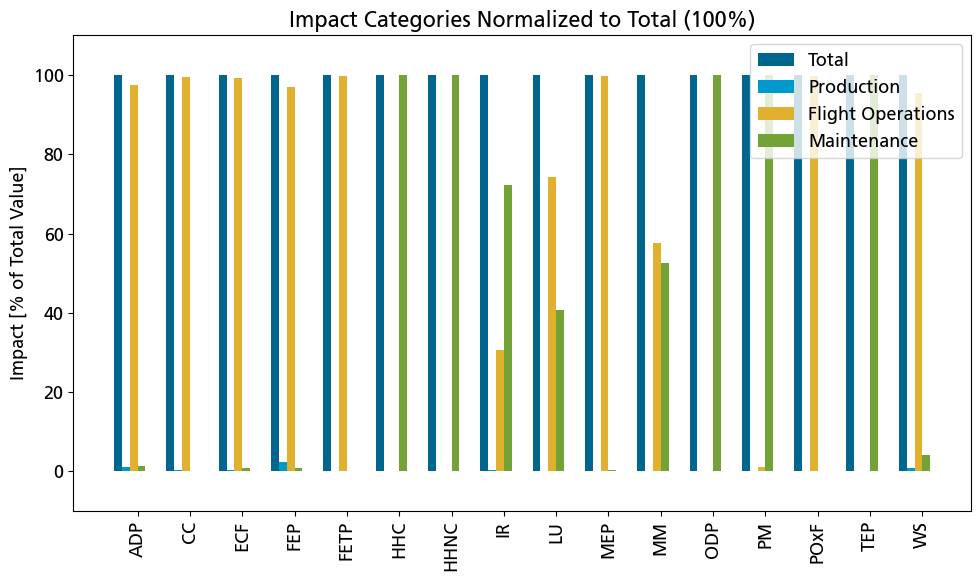

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Custom colors for each phase/area
colors = {
    "aggregated": blue,
    "production": light_blue,
    "maintenance": green,
    "flight_ops": yellow,
    "eol": red
}

plt.figure(figsize=(10,6))
bar_width = 0.15
x = range(len(impact_categories))

# Plot each area with normalized values and add error bars for quantiles
for i, area in enumerate(areas[:-1]):
    if area == "aggregated":
        # Set "Life" values in aggregated area as the baseline (100%)
        base_values = [mean[area][impact_category].get("Life", 0) for impact_category in reorder_list_alphabetically(impact_categories)]
        bar_values = [100] * len(impact_categories)  # 100% for all aggregated values
    else:
        # Calculate values as a percentage of the base "aggregated" values
        bar_values = [
            (mean[area].get(impact_category, 0) / base if base != 0 else 0) * 100
            for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)
        ]
        
    if area == 'aggregated': label = 'Total'
    if area == 'production': label = 'Production'
    if area == 'flight_ops': label = 'Flight Operations'
    if area == 'maintenance': label = 'Maintenance'
    if area == 'eol': label = 'End-of-Life'

    # Plot bars with custom colors and asymmetric error bars
    plt.bar(
        [a + bar_width * i for a in x],
        bar_values,
        width=bar_width,
        color=colors.get(area, gray),  # Use custom colors, defaulting to gray if not found
        label=label,
        capsize=5
    )

# Set x-ticks, labels, and rotate the labels by 90 degrees
plt.xticks(
    [a + bar_width * (len(areas) / 2) for a in x],
    reorder_list_alphabetically(impact_categories_translated),
    rotation=90,
    ha='center'
)

# Title and legend for clarity
plt.title("Impact Categories Normalized to Total (100%)")
plt.ylabel("Impact [% of Total Value]")
plt.legend(loc="upper right")
plt.ylim(-10, 110)  # Set y-axis limits to 0-200%

plt.tight_layout()
plt.show()


D250-TF results with error bars

[11.969802419407543, 10.26896305344414, 19.41260452025881, 13.564766222786687, 13.443958242914135, 20.35457801121798, 87.79117201080209, 48.690115977057154, 31.216218992984338, 4.484248221843686, 43.14370442453892, 79.41934650326462, 92.0266726965797, 4.264562283830529, 47.41559656702606, 13.133133134273564]
[10.914311988923757, 10.370004113372303, 18.38932568329176, 11.943198280978734, 11.603140844381528, 13.192047617714934, 45.695492854223254, 13.213545038833686, 13.964170252884017, 4.861872144391626, 11.218807767227432, 39.57501264743802, 54.096816335215046, 4.657201022498711, 27.796574718551952, 5.909560782790919]


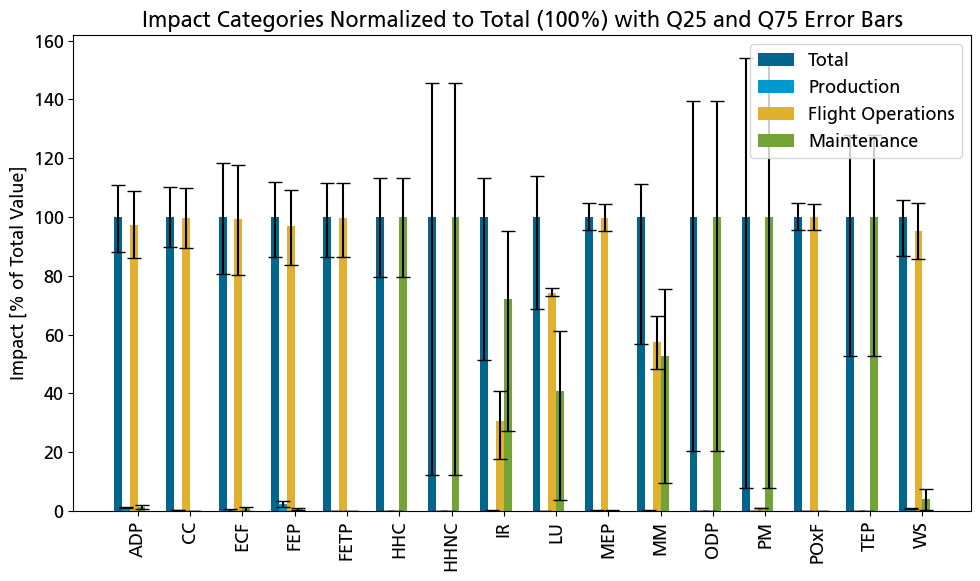

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Custom colors for each phase/area
colors = {
    "aggregated": blue,
    "production": light_blue,
    "maintenance": green,
    "flight_ops": yellow,
    "eol": red
}

plt.figure(figsize=(10,6))
bar_width = 0.15
x = range(len(impact_categories))

# Plot each area with normalized values and add error bars for quantiles
for i, area in enumerate(areas[:-1]):
    if area == "aggregated":
        # Set "Life" values in aggregated area as the baseline (100%)
        base_values = [mean[area][impact_category].get("Life", 0) for impact_category in reorder_list_alphabetically(impact_categories)]
        bar_values = [100] * len(impact_categories)  # 100% for all aggregated values
        q25_errors = [100 - (100 * q25[area][impact_category].get("Life", 0) / base) if base != 0 else 0
                      for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)]
        q75_errors = [(100 * q75[area][impact_category].get("Life", 0) / base) - 100 if base != 0 else 0
                      for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)]
        
        q25_errors = [abs(q25_errors[i]) for i in range(len(q25_errors))]
        q75_errors = [abs(q75_errors[i]) for i in range(len(q75_errors))]
        print(q25_errors), print(q75_errors)
    else:
        # Calculate values as a percentage of the base "aggregated" values
        bar_values = [
            (mean[area].get(impact_category, 0) / base if base != 0 else 0) * 100
            for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)
        ]
        q25_errors = [
            (mean[area].get(impact_category, 0) - q25[area].get(impact_category, 0)) / base * 100 if base != 0 else 0
            for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)
        ]
        q75_errors = [
            (q75[area].get(impact_category, 0) - mean[area].get(impact_category, 0)) / base * 100 if base != 0 else 0
            for impact_category, base in zip(reorder_list_alphabetically(impact_categories), base_values)
        ]
        
        q25_errors = [abs(q25_errors[i]) for i in range(len(q25_errors))]
        q75_errors = [abs(q75_errors[i]) for i in range(len(q75_errors))]
    
    # Combine q25 and q75 errors as a tuple for error bars
    error_bars = [q25_errors, q75_errors]
    
    if area == 'aggregated': label = 'Total'
    if area == 'production': label = 'Production'
    if area == 'flight_ops': label = 'Flight Operations'
    if area == 'maintenance': label = 'Maintenance'
    if area == 'eol': label = 'End-of-Life'

    # Plot bars with custom colors and asymmetric error bars
    plt.bar(
        [a + bar_width * i for a in x],
        bar_values,
        width=bar_width,
        color=colors.get(area, gray),  # Use custom colors, defaulting to gray if not found
        label=label,
        yerr=error_bars,
        capsize=5
    )

# Set x-ticks, labels, and rotate the labels by 90 degrees
plt.xticks(
    [a + bar_width * (len(areas) / 2) for a in x],
    reorder_list_alphabetically(impact_categories_translated),
    rotation=90,
    ha='center'
)

# Title and legend for clarity
plt.title("Impact Categories Normalized to Total (100%) with Q25 and Q75 Error Bars")
plt.ylabel("Impact [% of Total Value]")
plt.legend(loc="upper right")
# plt.ylim(-10, 170)  # Set y-axis limits to 0-200%

plt.tight_layout()
plt.show()


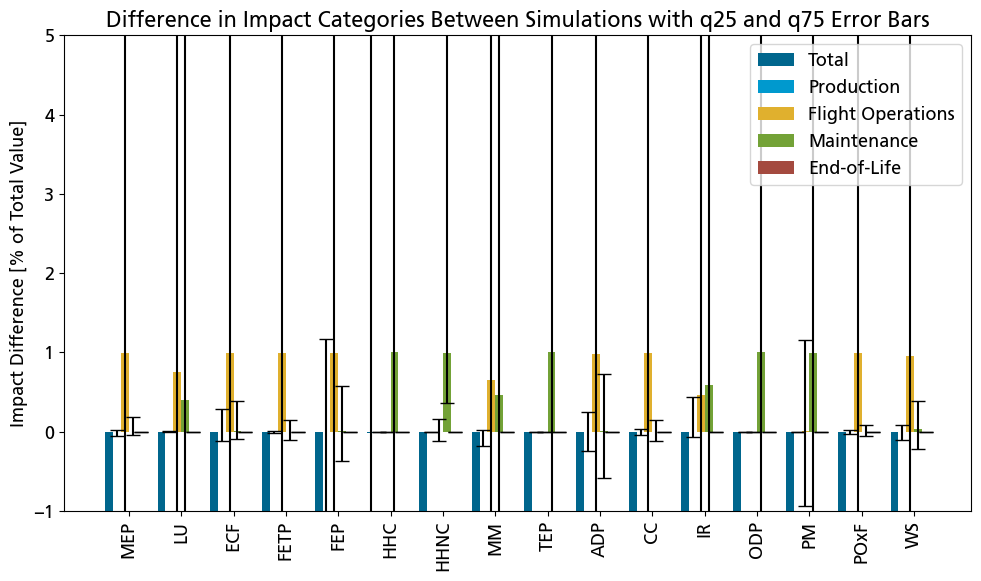

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Custom colors for each phase/area
colors = {
    "aggregated": blue,
    "production": light_blue,
    "maintenance": green,
    "flight_ops": yellow,
    "eol": red
}

plt.figure(figsize=(10,6))
bar_width = 0.15
x = range(len(impact_categories))

# Plot each area with the difference in values and adjusted error bars
for i, area in enumerate(areas):
    if area == "aggregated":
        # Calculate the difference between mean2 and mean for the baseline (100%)
        base_values_diff = [
            mean2[area][impact_category].get("Life", 0) - mean[area][impact_category].get("Life", 0)
            for impact_category in impact_categories
        ]
        bar_values = [diff for diff in base_values_diff]  # 100% baseline plus difference
        q25_errors = [
            abs(100 * (q25[area][impact_category].get("Life", 0) - mean[area][impact_category].get("Life", 0)) /
                base) if base != 0 else 0
            for impact_category, base in zip(impact_categories, base_values_diff)
        ]
        q75_errors = [
            abs(100 * (q75[area][impact_category].get("Life", 0) - mean[area][impact_category].get("Life", 0)) /
                base) if base != 0 else 0
            for impact_category, base in zip(impact_categories, base_values_diff)
        ]
    else:
        # Calculate the difference for non-aggregated areas
        bar_values = [
            (mean2[area].get(impact_category, 0) - mean[area].get(impact_category, 0)) /
            base if base != 0 else 0 * 100
            for impact_category, base in zip(impact_categories, base_values_diff)
        ]
        
        # Calculate combined error using root sum of squares for standard deviations
        combined_std = [
            np.sqrt(std[area].get(impact_category, 0)**2 + std2[area].get(impact_category, 0)**2)
            for impact_category in impact_categories
        ]
        
        # Calculate q25 and Q90 differences for error bars, using absolute values
        q25_errors = [
            abs((mean2[area].get(impact_category, 0) - q25[area].get(impact_category, 0)) /
                base * 100) if base != 0 else 0
            for impact_category, base in zip(impact_categories, base_values_diff)
        ]
        q75_errors = [
            abs((q75[area].get(impact_category, 0) - mean2[area].get(impact_category, 0)) /
                base * 100) if base != 0 else 0
            for impact_category, base in zip(impact_categories, base_values_diff)
        ]
    
    # Combine q25 and q75 errors as a tuple for error bars
    error_bars = [q25_errors, q75_errors]
    
    # Define labels for each area
    label_map = {
        'aggregated': 'Total',
        'production': 'Production',
        'flight_ops': 'Flight Operations',
        'maintenance': 'Maintenance',
        'eol': 'End-of-Life'
    }
    label = label_map.get(area, area)

    # Plot bars with custom colors and asymmetric error bars
    plt.bar(
        [a + bar_width * i for a in x],
        bar_values,
        width=bar_width,
        color=colors.get(area, gray),  # Use custom colors, defaulting to gray if not found
        label=label,
        yerr=error_bars,
        capsize=5
    )

# Set x-ticks, labels, and rotate the labels by 90 degrees
plt.xticks(
    [a + bar_width * (len(areas) / 2) for a in x],
    impact_categories_translated,
    rotation=90,
    ha='center'
)

# Title and legend for clarity
plt.title("Difference in Impact Categories Between Simulations with q25 and q75 Error Bars")
plt.ylabel("Impact Difference [% of Total Value]")
plt.legend(loc="upper right")
plt.ylim(-1, 5)  # Set y-axis limits as needed

plt.tight_layout()
plt.show()


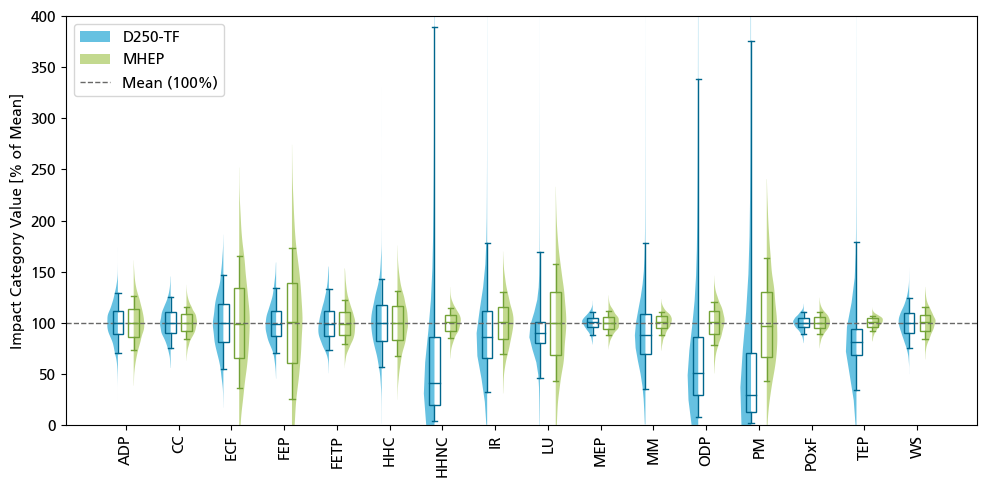

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 11})

# ------------------- Data Extraction and Processing -------------------

# Assuming impact_categories, result_list, and result_list2 are already defined

def process_results(result_list):
    # Step 1: Extract the Data
    data_dict = {impact_category: [] for impact_category in reorder_list_alphabetically(impact_categories)}

    for result in result_list:
        for impact_category in reorder_list_alphabetically(impact_categories):
            value = result['aggregated'][impact_category]['Life']
            data_dict[impact_category].append(value)

    # Step 2: Calculate the Means and Standard Deviations
    means = {}
    std_devs = {}

    for impact_category, values in data_dict.items():
        mean_value = np.mean(values)
        std_dev = np.std(values)
        means[impact_category] = mean_value
        std_devs[impact_category] = std_dev

    # Step 3: Filter Out Outliers
    filtered_data_dict = {}

    for impact_category, values in data_dict.items():
        mean_value = means[impact_category]
        std_dev = std_devs[impact_category]
        if std_dev != 0:
            filtered_values = [
                value for value in values
                if abs(value - mean_value) <= 3 * std_dev
            ]
        else:
            filtered_values = values
        filtered_data_dict[impact_category] = filtered_values

    # Step 4: Recalculate Means for Normalization
    filtered_means = {}

    for impact_category, values in filtered_data_dict.items():
        if values:
            filtered_mean = np.mean(values)
        else:
            filtered_mean = 0
        filtered_means[impact_category] = filtered_mean

    # Step 5: Normalize the Filtered Data
    normalized_data_dict = {}

    for impact_category, values in filtered_data_dict.items():
        mean_value = filtered_means[impact_category]
        if mean_value != 0:
            normalized_values = [(value / mean_value) * 100 for value in values]
        else:
            normalized_values = [0 for value in values]
        normalized_data_dict[impact_category] = normalized_values

    # Step 6: Prepare Data for Plotting
    normalized_data_to_plot = [
        normalized_data_dict[impact_category] for impact_category in reorder_list_alphabetically(impact_categories)
    ]

    return normalized_data_to_plot

# Process both result lists
normalized_data_to_plot1 = process_results(result_list)
normalized_data_to_plot2 = process_results(result_list2)

# ------------------- Create the Violin Plot -------------------

fig, ax = plt.subplots(figsize=(10,5))

positions = np.arange(1, len(impact_categories) + 1)
width = 0.8  # Total width for both violins

# Adjust the positions for left and right violins
positions_left = positions - width / 4 + 0.05
positions_right = positions + width / 4 - 0.05

# Plot the violin plots for result_list (left half)
parts1 = ax.violinplot(
    normalized_data_to_plot1,
    positions=positions_left,
    widths=width / 2,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for pc in parts1['bodies']:
    pc.set_facecolor(light_blue)
    pc.set_edgecolor('none')  # Remove edges
    pc.set_alpha(0.6)
    # Create left half of the violin
    path = pc.get_paths()[0]
    vertices = path.vertices
    mean_x = np.mean(vertices[:, 0])
    # Clip the x-values to create the left half
    vertices[vertices[:, 0] > mean_x, 0] = mean_x


# Plot the violin plots for result_list2 (right half)
parts2 = ax.violinplot(
    normalized_data_to_plot2,
    positions=positions_right,
    widths=width / 2,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for pc in parts2['bodies']:
    pc.set_facecolor(light_green)
    pc.set_edgecolor('none')  # Remove edges
    pc.set_alpha(0.6)
    # Create right half of the violin
    path = pc.get_paths()[0]
    vertices = path.vertices
    mean_x = np.mean(vertices[:, 0])
    # Clip the x-values to create the right half
    vertices[vertices[:, 0] < mean_x, 0] = mean_x


# ------------------- Add Boxplots -------------------

# Boxplot properties for result_list (left boxplots)
boxprops1 = dict(facecolor='none', color=blue)
medianprops1 = dict(color=blue)
whiskerprops1 = dict(color=blue)
capprops1 = dict(color=blue)
flierprops1 = dict(marker='o', markerfacecolor=light_blue, markersize=3, markeredgecolor='none')

ax.boxplot(
    normalized_data_to_plot1,
    positions=positions_left,
    widths=width / 4,
    whis=[5, 95],
    notch=False,
    patch_artist=True,
    boxprops=boxprops1,
    medianprops=medianprops1,
    whiskerprops=whiskerprops1,
    capprops=capprops1,
    flierprops=flierprops1,
    manage_ticks=False,
    showfliers=False    
)

# Boxplot properties for result_list2 (right boxplots)
boxprops2 = dict(facecolor='none', color=green)
medianprops2 = dict(color=green)
whiskerprops2 = dict(color=green)
capprops2 = dict(color=green)
flierprops2 = dict(marker='o', markerfacecolor=light_green, markersize=3, markeredgecolor='none')

ax.boxplot(
    normalized_data_to_plot2,
    positions=positions_right,
    widths=width / 4,
    whis=[10, 90],
    notch=False,
    patch_artist=True,
    boxprops=boxprops2,
    medianprops=medianprops2,
    whiskerprops=whiskerprops2,
    capprops=capprops2,
    flierprops=flierprops2,
    manage_ticks=False,
    showfliers=False
)

# ------------------- Customize the Plot -------------------

# Set the plot title and labels
ax.set_ylabel('Impact Category Value [% of Mean]')

# Set x-ticks and labels at the center between the two violins
ax.set_xticks(positions)
ax.set_xticklabels(reorder_list_alphabetically(impact_categories_translated), rotation=90)

# Set y-axis limits
ax.set_ylim(0, 400)  # Adjust as needed

# Add a horizontal line at y=100% to indicate the mean
ax.axhline(y=100, color=gray, linestyle='--', linewidth=1)

# ------------------- Add Legend -------------------

# Create custom legend entries
legend_elements = [
    Patch(facecolor=light_blue, edgecolor='none', alpha=0.6, label='D250-TF'),
    Patch(facecolor=light_green, edgecolor='none', alpha=0.6, label='MHEP'),
    # Line2D([0], [0], color=blue, lw=2, label='Box Plot 1'),
    # Line2D([0], [0], color=green, lw=2, label='Box Plot 2'),
    Line2D([0], [0], color=gray, linestyle='--', lw=1, label='Mean (100%)')
]

ax.legend(handles=legend_elements, loc='upper left')

# ------------------- Show the Plot -------------------

plt.tight_layout()
plt.savefig('lyfe_violin_plot.png', dpi=900)
plt.show()


Plot comparison of result_list and result_list2 per lifecycle phase

C:\Users\hoel_m0\AppData\Local\Temp\ipykernel_26360\2391427705.py:7: RuntimeWarning: invalid value encountered in double_scalars
  production_1 = [mean['production'][impact_category] / mean['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
C:\Users\hoel_m0\AppData\Local\Temp\ipykernel_26360\2391427705.py:8: RuntimeWarning: invalid value encountered in double_scalars
  production_2 = [mean2['production'][impact_category] / mean['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
C:\Users\hoel_m0\AppData\Local\Temp\ipykernel_26360\2391427705.py:18: RuntimeWarning: invalid value encountered in double_scalars
  production_1_q25 = [abs(q25['production'][impact_category] / mean['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
C:\Users\hoel_m0\AppData\Local\Temp\ipykernel_26360\2391427705.py:19: RuntimeWarning: invalid value encountered in

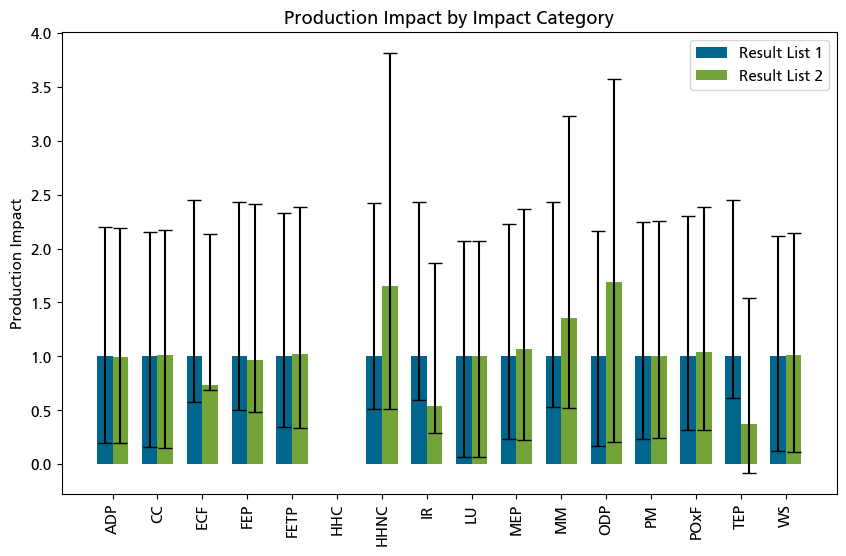

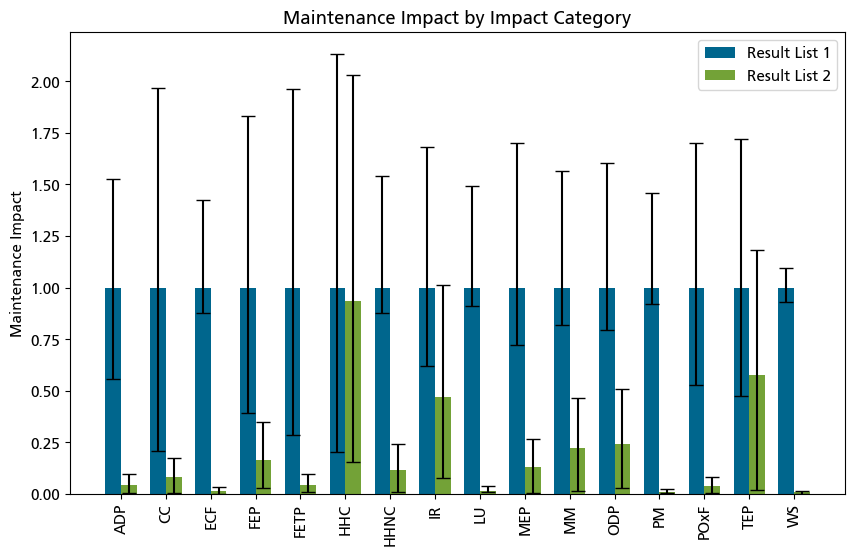

In [16]:
# create a bar plot, with error bars for the quantiles
# the x axis has the impact categories, the y axis has the mean value of the impact category of result_list
# each datapoint has one bar for the production in result_list and one bar for the production in result_list2

total_1 = [mean['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life'] for impact_category in reorder_list_alphabetically(impact_categories)]
total_2 = [mean2['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life'] for impact_category in reorder_list_alphabetically(impact_categories)]
production_1 = [mean['production'][impact_category] / mean['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
production_2 = [mean2['production'][impact_category] / mean['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_1 = [mean['flight_ops'][impact_category] / mean['flight_ops'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_2 = [mean2['flight_ops'][impact_category] / mean['flight_ops'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_1 = [mean['maintenance'][impact_category] / mean['maintenance'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_2 = [mean2['maintenance'][impact_category] / mean['maintenance'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_1 = [mean['eol'][impact_category] / mean['eol'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_2 = [mean2['eol'][impact_category] / mean['eol'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]

total_1_q25 = [abs(q25['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
total_1_q75 = [abs(q75['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
production_1_q25 = [abs(q25['production'][impact_category] / mean['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
production_1_q75 = [abs(q75['production'][impact_category] / mean['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_1_q25 = [abs(q25['flight_ops'][impact_category] / mean['flight_ops'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_1_q75 = [abs(q75['flight_ops'][impact_category] / mean['flight_ops'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_1_q25 = [abs(q25['maintenance'][impact_category] / mean['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_1_q75 = [abs(q75['maintenance'][impact_category] / mean['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_1_q25 = [abs(q25['eol'][impact_category] / mean['eol'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_1_q75 = [abs(q75['eol'][impact_category] / mean['eol'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]

total_2_q25 = [abs(q252['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
total_2_q75 = [abs(q752['aggregated'][impact_category]['Life'] / mean['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
production_2_q25 = [abs(q252['production'][impact_category] / mean['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
production_2_q75 = [abs(q752['production'][impact_category] / mean['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_2_q25 = [abs(q252['flight_ops'][impact_category] / mean['flight_ops'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# flight_ops_2_q75 = [abs(q752['flight_ops'][impact_category] / mean['flight_ops'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_2_q25 = [abs(q252['maintenance'][impact_category] / mean['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
maintenance_2_q75 = [abs(q752['maintenance'][impact_category] / mean['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_2_q25 = [abs(q252['eol'][impact_category] / mean['eol'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# eol_2_q75 = [abs(q752['eol'][impact_category] / mean['eol'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]

# non-normalised lists
# total_1 = [mean['aggregated'][impact_category]['Life'] for impact_category in reorder_list_alphabetically(impact_categories)]
# total_2 = [mean2['aggregated'][impact_category]['Life'] for impact_category in reorder_list_alphabetically(impact_categories)]
# production_1 = [mean['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# production_2 = [mean2['production'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_1 = [mean['maintenance'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_2 = [mean2['maintenance'][impact_category] for impact_category in reorder_list_alphabetically(impact_categories)]
# total_1_q25 = [abs(q25['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
# total_1_q75 = [abs(q75['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
# production_1_q25 = [abs(q25['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# production_1_q75 = [abs(q75['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_1_q25 = [abs(q25['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_1_q75 = [abs(q75['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# total_2_q25 = [abs(q252['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
# total_2_q75 = [abs(q752['aggregated'][impact_category]['Life']) for impact_category in reorder_list_alphabetically(impact_categories)]
# production_2_q25 = [abs(q252['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# production_2_q75 = [abs(q752['production'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_2_q25 = [abs(q252['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]
# maintenance_2_q75 = [abs(q752['maintenance'][impact_category]) for impact_category in reorder_list_alphabetically(impact_categories)]

### total plot

# plt.figure(figsize=(10,6))

# bar_width = 0.35
# x = np.arange(len(impact_categories))

# plt.bar(x, total_1, bar_width, yerr=[total_1_q25, total_1_q75], capsize=5, color=blue, label='Result List 1')
# plt.bar(x + bar_width, total_2, bar_width, yerr=[total_2_q25, total_2_q75], capsize=5, color=green, label='Result List 2')

# plt.ylabel('Total Impact')
# plt.title('Total Impact by Impact Category')

# plt.xticks(x + bar_width / 2, reorder_list_alphabetically(impact_categories_translated), rotation=90)
# plt.legend()

### production plot

plt.figure(figsize=(10,6))

bar_width = 0.35
x = np.arange(len(impact_categories))

plt.bar(x, production_1, bar_width, yerr=[production_1_q25, production_1_q75], capsize=5, color=blue, label='Result List 1')
plt.bar(x + bar_width, production_2, bar_width, yerr=[production_2_q25, production_2_q75], capsize=5, color=green, label='Result List 2')

plt.ylabel('Production Impact')
plt.title('Production Impact by Impact Category')

plt.xticks(x + bar_width / 2, reorder_list_alphabetically(impact_categories_translated), rotation=90)
plt.legend()

### flight ops plot

# plt.figure(figsize=(10,6))

# plt.bar(x, flight_ops_1, bar_width, yerr=[flight_ops_1_q25, flight_ops_1_q75], capsize=5, color=blue, label='Result List 1')
# plt.bar(x + bar_width, flight_ops_2, bar_width, yerr=[flight_ops_2_q25, flight_ops_2_q75], capsize=5, color=green, label='Result List 2')

# plt.ylabel('Flight Operations Impact')
# plt.title('Flight Operations Impact by Impact Category')

# plt.xticks(x + bar_width / 2, reorder_list_alphabetically(impact_categories_translated), rotation=90)
# plt.legend()

### maintenance plot

plt.figure(figsize=(10,6))

plt.bar(x, maintenance_1, bar_width, yerr=[maintenance_1_q25, maintenance_1_q75], capsize=5, color=blue, label='Result List 1')
plt.bar(x + bar_width, maintenance_2, bar_width, yerr=[maintenance_2_q25, maintenance_2_q75], capsize=5, color=green, label='Result List 2')

plt.ylabel('Maintenance Impact')
plt.title('Maintenance Impact by Impact Category')

plt.xticks(x + bar_width / 2, reorder_list_alphabetically(impact_categories_translated), rotation=90)
plt.legend()

### eol plot

# plt.figure(figsize=(10,6))

# plt.bar(x, eol_1, bar_width, yerr=[eol_1_q25, eol_1_q90], capsize=5, color=blue, label='Result List 1')
# plt.bar(x + bar_width, eol_2, bar_width, yerr=[eol_2_q25, eol_2_q90], capsize=5, color=green, label='Result List 2')

# plt.ylabel('End-of-Life Impact')
# plt.title('End-of-Life Impact by Impact Category')

# plt.xticks(x + bar_width / 2, impact_categories, rotation=90)
# plt.legend()





TEP
ECF
174105878.0611485
74179821.73457882
252455444.8060633
128130210.40970747
8811370.314861206
243633866.317878
IR
CC
6946529.44575794
5873121.09075406
7998884.120245415
7030371.079909152
5981828.798488434
8082947.5793769965
ECF
MM
11.868831592442435
5.603199773039566
17.04029855425028
16.036797752342693
9.887499543030081
22.294948802705058


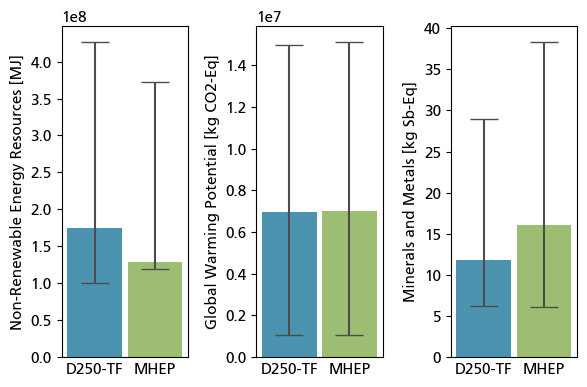

In [24]:
# Define impact categories and labels
categories = ['ECF', 'CC', 'MM']
labels = [
    'Non-Renewable Energy Resources [MJ]',
    'Global Warming Potential [kg CO2-Eq]',
    'Minerals and Metals [kg Sb-Eq]'
]
bar_width = 0.2

# Create a figure with 1 row and 3 columns for subplots
fig, axes = plt.subplots(1, len(categories), figsize=(6, 4))

for i, (impact_category, label) in enumerate(zip(categories, labels)):
    # Extract "production" data for the current impact category
    production_1 = mean['production'].get(reverse_translate(impact_category), 0)
    production_2 = mean2['production'].get(reverse_translate(impact_category), 0)
    production_1_q25 = abs(q25['production'].get(reverse_translate(impact_category), 0))
    production_1_q75 = abs(q75['production'].get(reverse_translate(impact_category), 0))
    production_2_q25 = abs(q252['production'].get(reverse_translate(impact_category), 0))
    production_2_q75 = abs(q752['production'].get(reverse_translate(impact_category), 0))

    print(reverse_translate(impact_category))
    
    # Plot bars with asymmetric error bars in the current subplot
    error_kw = {'ecolor': '#4d4d4d', 'capsize': 10}
    axes[i].bar(0, [production_1], bar_width, yerr=[[production_1_q25], [production_1_q75]], error_kw=error_kw, color=blue, alpha=0.7)
    axes[i].bar(bar_width+0.02, [production_2], bar_width, yerr=[[production_2_q25], [production_2_q75]], error_kw=error_kw, color=green, alpha=0.7)

    # Set y-label for the impact category
    axes[i].set_ylabel(label)
    
    # Set x-ticks to label the two bars as 'Result List 1' and 'Result List 2'
    axes[i].set_xticks([0, bar_width+0.02])
    axes[i].set_xticklabels(['D250-TF', 'MHEP'])
    axes[i].tick_params(axis='x', length=0)
    
    print(impact_category)
    print(production_1)
    print(production_1_q25)
    print(production_1_q75)
    print(production_2)
    print(production_2_q25)
    print(production_2_q75)
    


# Adjust layout for better spacing
plt.tight_layout()
plt.savefig('comparison_production.png', dpi=600)
plt.show()





TEP
ECF
11.868831592442435
5.603199773039566
17.04029855425028
16.036797752342693
9.887499543030081
22.294948802705058
IR
CC
11.868831592442435
5.603199773039566
17.04029855425028
16.036797752342693
9.887499543030081
22.294948802705058
ECF
MM
11.868831592442435
5.603199773039566
17.04029855425028
16.036797752342693
9.887499543030081
22.294948802705058


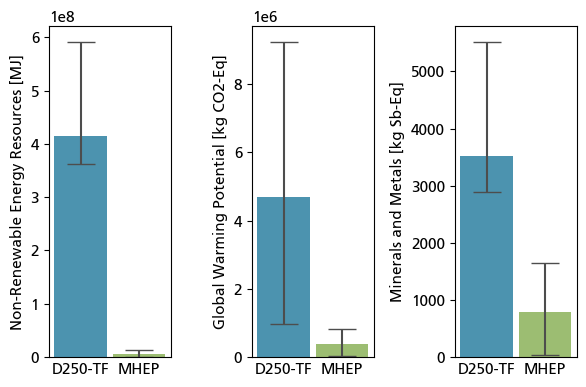

In [23]:
# Create a figure with 1 row and 3 columns for subplots
fig, axes = plt.subplots(1, len(categories), figsize=(6, 4))

for i, (impact_category, label) in enumerate(zip(categories, labels)):
    # Extract "maintenance" data for the current impact category
    maintenance_1 = mean['maintenance'].get(reverse_translate(impact_category), 0)
    maintenance_2 = mean2['maintenance'].get(reverse_translate(impact_category), 0)
    maintenance_1_q25 = abs(q25['maintenance'].get(reverse_translate(impact_category), 0))
    maintenance_1_q75 = abs(q75['maintenance'].get(reverse_translate(impact_category), 0))
    maintenance_2_q25 = abs(q252['maintenance'].get(reverse_translate(impact_category), 0))
    maintenance_2_q75 = abs(q752['maintenance'].get(reverse_translate(impact_category), 0))

    print(reverse_translate(impact_category))
    
    # Plot bars with asymmetric error bars in the current subplot
    error_kw = {'ecolor': '#4d4d4d', 'capsize': 10}
    axes[i].bar(0, [maintenance_1], bar_width, yerr=[[maintenance_1_q25], [maintenance_1_q75]], error_kw=error_kw, color=blue, alpha=0.7)
    axes[i].bar(bar_width+0.02, [maintenance_2], bar_width, yerr=[[maintenance_2_q25], [maintenance_2_q75]], error_kw=error_kw, color=green, alpha=0.7)

    # Set y-label for the impact category
    axes[i].set_ylabel(label)
    
    # Set x-ticks to label the two bars as 'Result List 1' and 'Result List 2'
    axes[i].set_xticks([0, bar_width+0.02])
    axes[i].set_xticklabels(['D250-TF', 'MHEP'])
    axes[i].tick_params(axis='x', length=0)
    
    print(impact_category)
    print(production_1)
    print(production_1_q25)
    print(production_1_q75)
    print(production_2)
    print(production_2_q25)
    print(production_2_q75)

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig('comparison_maintenance.png', dpi=600)
plt.show()
